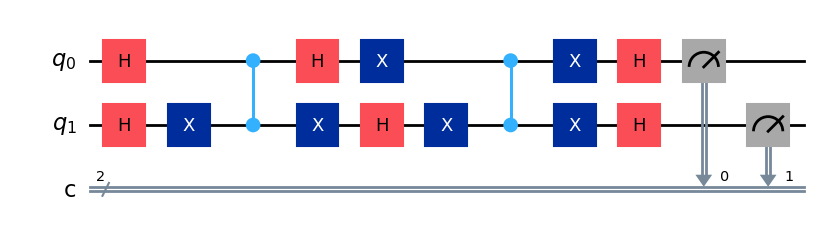

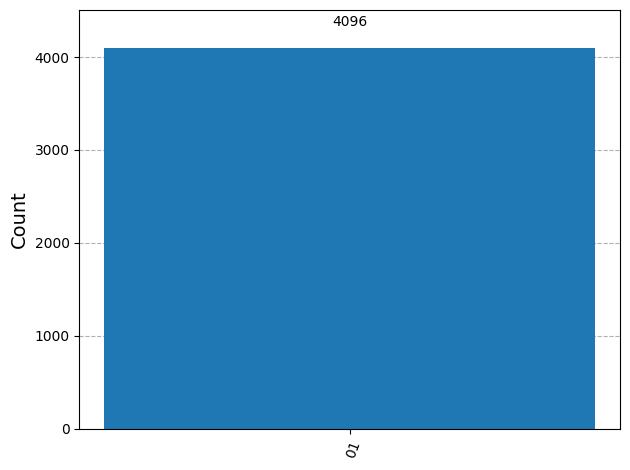

In [5]:
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def present_run(qc):

    simulator = AerSimulator()

    # Transpile and run
    from qiskit import transpile

    compiled = transpile(qc, simulator)
    job = simulator.run(compiled, shots=2**12)
    result = job.result()

    counts = result.get_counts()

    display(qc.draw('mpl'))
    display(plot_histogram(counts))

def oracle(index, qc):
    # index 0 = |00>, index 1 = |01>, index 2 = |10>, index 3 = |11>
    if index == 3:       # |11> 
        qc.cz(0, 1)

    elif index == 1:     # |10>
        qc.x(1)
        qc.cz(0, 1)
        qc.x(1)

    elif index == 2:     # |01> 
        qc.x(0)
        qc.cz(0, 1)
        qc.x(0)

    elif index == 0:     # |00>
        qc.x([0, 1])
        qc.cz(0, 1)
        qc.x([0, 1])


qc = QuantumCircuit(2,2)
# 1: Hadamard gate to create superposition
qc.h([0, 1])

# 2: Oracle
# CZ flips the phase of |11> only, |11> is target state so the oracle has to make the desired state look like |11> 
oracle(1, qc)

# 3: Diffusion operator (reflection about the mean?)
# H on all qubits
qc.h([0, 1])
# X on all qubits
qc.x([0, 1])
# Multi-controlled Z (for 2 qubits)
qc.cz(0, 1)
# X on all qubits
qc.x([0, 1])
# H on all qubits
qc.h([0, 1])


# measurement and display code
qc.measure([0, 1], [0, 1])
present_run(qc)
